In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import pickle
import sys; sys.path.insert(0, '..')

from src.migration_matrix_cci import upper_threshold, fitted_cdf
from src.lifetime_model import matrix_lifetime
from src.plot_function import plot_lifetime

pd.options.display.float_format = '{:.3f}'.format
np.set_printoptions(suppress = True)
warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category = RuntimeWarning)
warnings.filterwarnings('ignore', category = UserWarning)

In [3]:
# Import unbias migration matrix
average_matrix = pd.read_parquet(
    '../data/processed/average_matrix.parquet',
    engine = 'pyarrow'
)

# Show matrix
average_matrix

del12,0,1,2,3,4
del,,,,,
0,0.671,0.246,0.054,0.015,0.013
1,0.018,0.513,0.316,0.081,0.072
2,0.004,0.066,0.453,0.227,0.251
3,0.005,0.022,0.086,0.190,0.697
4,0.000,0.000,0.000,0.000,1.000


In [4]:
# Import FWL Model
with open("../model/fwl_model.pkl", "rb") as f:
    model = pickle.load(f)

# Constant parameters
MODEL_NAME = "MODEL_2188" #Randomly selected

# Get model
model = model[MODEL_NAME]
final_vars = list(model.params[1:].index)
print(f"Final MEV(s): {final_vars}")

Final MEV(s): ['BROMO_MA12M', 'CAPU_MA12M_LAG9M', 'FDI_MA12M_LAG12M']


In [5]:
# Import MEV Data
mev_transformed = pd.read_parquet(
    '../data/processed/mev_transformed.parquet',
    engine = 'pyarrow'
)

# Select forecasting MEV(s)
mev_transformed = mev_transformed[final_vars].loc["2020-01-31":"2022-12-31"]
mev_transformed.insert(0, "const", 1) #Add constant

# Show table
mev_transformed.head(5)

,const,BROMO_MA12M,CAPU_MA12M_LAG9M,FDI_MA12M_LAG12M
Date,,,,
2020-01-31,1,20458443.333,68.434,254679.249
2020-02-29,1,20513529.000,68.228,255174.833
2020-03-31,1,20644383.667,67.829,255583.827
2020-04-30,1,20803575.250,67.605,256841.282
2020-05-31,1,20986009.000,67.320,258947.200


In [6]:
# Prediction
pred = model.predict(mev_transformed)
pred_yearly = np.array(pred.resample("YE").mean()) #To yearly basis
print("Forecasting CCI")
for i, p in enumerate(pred_yearly):
    print(f"Year {i + 1}: {p:.4f}")

Forecasting CCI
Year 1: 1.3244
Year 2: 3.7508
Year 3: 2.7894


## Predicted migration matrix
Based on the predicted CCI or Z-Index, the fitted migration matrix is able to compute by applying the formula:

$$
P_i(j) = \Phi\left(\frac{x_{i+1}^j - \sqrt{\rho}\, \hat{z_t}}{\sqrt{1 - \rho}}\right)
- \Phi\left(\frac{x_i^j - \sqrt{\rho}\, \hat{z_t}}{\sqrt{1 - \rho}}\right)
$$

where;
- $\hat{z_t}$ denotes the predicted CCI or Z-Index at time $t$.

In [7]:
# Import Rho (Asset Correlation)
with open("../model/rho.pkl", "rb") as f:
    rho = pickle.load(f)

print(f"Rho: {rho:.4f}")

Rho: 0.0577


In [8]:
# Fitted upper migration matrix
upper = upper_threshold(average_matrix)
fitted_upper = (
    upper[None, :, :] - (np.sqrt(rho) * pred_yearly[:, None, None]) #Shape (1,4,5) * (3,1,1)
) / np.sqrt(1 - rho)

# Fitted PiT Migration matrix
fitted_matrix = fitted_cdf(fitted_upper)

# Show result
fitted_matrix

array([[[0.78335441, 0.1771722 , 0.02852784, 0.00657293, 0.00437262],
        [0.03427644, 0.62416063, 0.25809874, 0.05002705, 0.03343713],
        [0.00836936, 0.10796129, 0.53393142, 0.19600638, 0.15373154],
        [0.0094152 , 0.0390713 , 0.13040809, 0.2407582 , 0.58034722]],

       [[0.91680537, 0.07398691, 0.00729726, 0.00127437, 0.00063609],
        [0.11103771, 0.73236189, 0.13288697, 0.01622308, 0.00749035],
        [0.03656089, 0.23996135, 0.56149837, 0.10945845, 0.05252095],
        [0.04018489, 0.10452805, 0.23005221, 0.27975218, 0.34548268]],

       [[0.87410799, 0.1088588 , 0.01306434, 0.00254778, 0.00142109],
        [0.07229626, 0.70724834, 0.17992778, 0.02644485, 0.01408277],
        [0.0211812 , 0.18178395, 0.56995037, 0.14375427, 0.08333022],
        [0.02349352, 0.07377831, 0.19144705, 0.27471174, 0.43656938]]])

In [9]:
# Lifetime matrix multiplication
cum_pd = matrix_lifetime(
    avg_matrix = average_matrix,
    pred_matrix = fitted_matrix,
    years = 10,
    mean_reversion = False
)

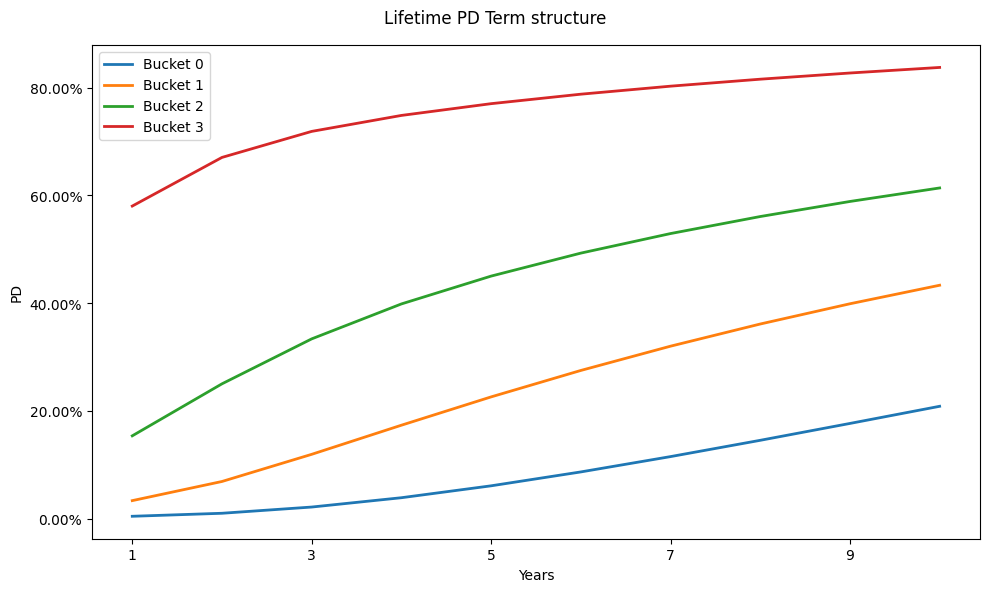

In [10]:
# Plot
plot_lifetime(cum_pd)

In [11]:
# Save lifetime PD Term structure result
with open('../model/lifetime_pd_term_structure.pkl', 'wb') as f:
    pickle.dump(cum_pd, f)